In [1]:
# general python modules for scientific analysis
import sys, pathlib, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

# add the physion path:
sys.path.append('../../../physion/src')
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.process_NWB import EpisodeData
from physion.dataviz.raw import plot as plot_raw
from physion.dataviz.episodes.trial_average import plot as plot_trial_average
from physion.utils import plot_tools as pt

# disable UserWarning from pynwb
#import warnings
#warnings.filterwarnings("ignore")

"skimage" module not found


In [15]:
def compute_high_arousal_cond(behav_episodes,
                              pupil_threshold,
                              running_speed_threshold):
    # HAcond: high arousal condition
    if pupil_threshold is not None:
        HAcond = (behav_episodes.pupil_diameter.mean(axis=1)>pupil_threshold)
    else:
        HAcond = (behav_episodes.running_speed.mean(axis=1)>running_speed_threshold) 
    return HAcond

def compute_high_movement_cond(behav_episodes,
                               running_speed_threshold):
    # HMcond: high movement condition
    if running_speed_threshold is not None:
        HMcond = (behav_episodes.running_speed.mean(axis=1)>running_speed_threshold) 
    return HMcond

    
def plot_behavior_in_episodes(data,
                              ax=None,
                              running_speed_threshold=0.1,
                              pupil_threshold=None):
    
    protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

    if ax is None:
        fig, ax = plt.subplots(1, figsize=(2,1.3))
        plt.subplots_adjust(wspace=0.3, hspace=0.3)
    else:
        fig = None

    HAcount, LAcount = [], []
    for p, protocol in enumerate(protocols):

        behav_episodes = EpisodeData(data, 
                             quantities=['Pupil', 'Running-Speed'],
                             protocol_name=protocol,
                             prestim_duration=0,
                             verbose=False)
        
        # HAcond: high arousal condition
        HAcond = compute_high_arousal_cond(behav_episodes, pupil_threshold, running_speed_threshold)
            
        ax.plot(behav_episodes.pupil_diameter.mean(axis=1)[~HAcond],
                behav_episodes.running_speed.mean(axis=1)[~HAcond], 'o', color='tab:blue')
        ax.plot(behav_episodes.pupil_diameter.mean(axis=1)[HAcond],
                behav_episodes.running_speed.mean(axis=1)[HAcond], 'o', color='tab:orange')
        
        HAcount.append(np.sum(HAcond))
        LAcount.append(np.sum(~HAcond))
        
    ax.set_ylabel('run. speed (cm/s)')
    ax.set_xlabel('pupil size (mm)')
    ax.annotate('\n n=%i ep.' % np.sum(HAcount), (0, 1), color='tab:orange', xycoords='axes fraction', va='top')
    ax.annotate(' n=%i ep.' % np.sum(LAcount), (0, 1), color='tab:blue', xycoords='axes fraction', va='top')
    return fig, ax

def set_pupil_run(inset):
    
    inset.set_xticks([])
    inset.set_xlabel('pup.', fontsize=6, labelpad=1)
    
    inset.set_yticks([])
    inset.set_ylabel('run', fontsize=6, labelpad=1)
    
    for axis in ['bottom','left']:
        inset.spines[axis].set_linewidth(0.4)
    

    
def plot_average_visually_evoked_activity(data,
                                          roiIndex=None,
                                          pupil_threshold=None,
                                          running_speed_threshold=0.1):
    
    protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

    # prepare array for final results (averaged over sessions)
    RESULTS = {}
    for protocol in protocols:
        RESULTS[protocol] = {'significant':[], 'response':[], 'session':[]}


    fig, AX = plt.subplots(5, len(protocols),
                              figsize=(7,5))
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)

    for p, protocol in enumerate(protocols):

        behav_episodes = EpisodeData(data, 
                             quantities=['Pupil', 'Running-Speed'],
                             protocol_name=protocol,
                             prestim_duration=0,
                             verbose=False)
        
        # HAcond: high arousal condition
        HAcond = compute_high_arousal_cond(behav_episodes, pupil_threshold, running_speed_threshold)
        
        episodes = EpisodeData(data,
                               quantities=['dFoF'],
                               protocol_name=protocol,
                               verbose=False)
        varied_keys = [k for k in episodes.varied_parameters.keys() if k!='repeat']
        varied_values = [episodes.varied_parameters[k] for k in varied_keys]

        AX[0][p].annotate(protocol.replace('Natural-Images-4-repeats','natural-images'),
                          (0.5,1.4),
                          xycoords='axes fraction', ha='center')

        i=0
        for values in itertools.product(*varied_values):

            stim_cond = episodes.find_episode_cond(key=varied_keys, value=values)
            
            inset = pt.inset(AX[i][p], [0.6, 0.9, 0.2, 0.15])
            inset.plot(behav_episodes.pupil_diameter.mean(axis=1)[~HAcond & stim_cond],
                       behav_episodes.running_speed.mean(axis=1)[~HAcond & stim_cond],
                       'o', color='tab:blue', ms=0.5)
            inset.plot(behav_episodes.pupil_diameter.mean(axis=1)[HAcond & stim_cond],
                       behav_episodes.running_speed.mean(axis=1)[HAcond & stim_cond],
                       'o', color='tab:orange', ms=0.5)
            set_pupil_run(inset)
            
            if np.sum(~HAcond & stim_cond)>1:
                plot_trial_average(episodes, 
                                   roiIndex=roiIndex,
                                   condition=stim_cond & (~HAcond),
                                   with_std=False, with_stim=False,
                                   color='tab:blue',
                                   AX=[[AX[i][p]]], no_set=True)
            
            if np.sum(HAcond & stim_cond)>1:
                plot_trial_average(episodes, 
                                   roiIndex=roiIndex,
                                   condition=stim_cond & HAcond,
                                   with_std=False, with_stim=True,
                                   color='tab:orange',
                                   AX=[[AX[i][p]]], no_set=True)

            RESULTS[protocol]['significant'].append([])
            RESULTS[protocol]['response'].append([])
            RESULTS[protocol]['session'].append([])
            i+=1

    if roiIndex is None:
        AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                        data.filename.replace('.nwb',''),data.nROIs),
                           (0, 0),
                          xycoords='axes fraction')
    else:
        AX[-1][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                           (0, 0), xycoords='axes fraction')

    pt.set_common_ylims(AX)
    for ax in pt.flatten(AX):
        ax.axis('off')
        if np.isfinite(ax.dataLim.x0) and ax==AX[0][0]:
            pt.draw_bar_scales(ax,
                               Xbar=1., Xbar_label='1s',
                               Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)
    pt.set_common_xlims(AX)
    
    return fig

<>:143: SyntaxWarning: invalid escape sequence '\p'
<>:157: SyntaxWarning: invalid escape sequence '\D'
<>:237: SyntaxWarning: invalid escape sequence '\p'
<>:251: SyntaxWarning: invalid escape sequence '\D'
<>:143: SyntaxWarning: invalid escape sequence '\p'
<>:157: SyntaxWarning: invalid escape sequence '\D'
<>:237: SyntaxWarning: invalid escape sequence '\p'
<>:251: SyntaxWarning: invalid escape sequence '\D'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_33992\3496637583.py:143: SyntaxWarning: invalid escape sequence '\p'
  AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_33992\3496637583.py:157: SyntaxWarning: invalid escape sequence '\D'
  Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_33992\3496637583.py:237: SyntaxWarning: invalid escape sequence '\p'
  AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%

In [75]:
def plot_average_visually_evoked_activity2(data,
                                          roiIndex=None,
                                          running_speed_threshold=0.1):
    
    protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

    # prepare array for final results (averaged over sessions)
    RESULTS = {}
    for protocol in protocols:
        RESULTS[protocol] = {'significant':[], 'response':[], 'session':[]}


    fig, AX = plt.subplots(5, len(protocols),
                              figsize=(7,5))
    pt.plt.subplots_adjust(wspace=0.3, hspace=0.3)

    for p, protocol in enumerate(protocols):

        behav_episodes = EpisodeData(data, 
                             quantities=['Pupil', 'Running-Speed'],
                             protocol_name=protocol,
                             prestim_duration=0,
                             verbose=False)
        
        # HMcond: high movement condition
        HMcond = compute_high_movement_cond(behav_episodes, running_speed_threshold)
        
        episodes = EpisodeData(data,
                               quantities=['dFoF'],
                               protocol_name=protocol,
                               verbose=False)
        varied_keys = [k for k in episodes.varied_parameters.keys() if k!='repeat']
        varied_values = [episodes.varied_parameters[k] for k in varied_keys]

        AX[0][p].annotate(protocol.replace('Natural-Images-4-repeats','natural-images'),
                          (0.5,1.4),
                          xycoords='axes fraction', ha='center')

        i=0
        for values in itertools.product(*varied_values):

            stim_cond = episodes.find_episode_cond(key=varied_keys, value=values)

            #inset
            inset = pt.inset(AX[i][p], [0.55, 0.9, 0.3, 0.2])
            rest = sum(stim_cond & (~HMcond))
            run  = sum(stim_cond & HMcond)
            inset.pie([rest, run], 
                       autopct='%1.1f%%', 
                       colors = ['tab:blue', 'tab:orange'], 
                       textprops={'fontsize': 5}, 
                       #labeldistance=0.5)  # Move labels outside
                       pctdistance=2  )  # Move percentage text closer to the edge

            #rest trace
            if np.sum(~HMcond & stim_cond)>1:
                plot_trial_average(episodes, 
                                   roiIndex=roiIndex,
                                   condition=stim_cond & (~HMcond),
                                   with_std=False, with_stim=False,
                                   color='tab:blue',
                                   AX=[[AX[i][p]]], no_set=True)
            #running trace
            if np.sum(HMcond & stim_cond)>1:
                plot_trial_average(episodes, 
                                   roiIndex=roiIndex,
                                   condition=stim_cond & HMcond,
                                   with_std=False, with_stim=True,
                                   color='tab:orange',
                                   AX=[[AX[i][p]]], no_set=True)

            RESULTS[protocol]['significant'].append([])
            RESULTS[protocol]['response'].append([])
            RESULTS[protocol]['session'].append([])
            i+=1

    if roiIndex is None:
        AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
                                                        data.filename.replace('.nwb',''),data.nROIs),
                           (0, 0),
                          xycoords='axes fraction')
    else:
        AX[-1][0].annotate('roi #%i ,   rec: %s' % (1+roiIndex, data.filename.replace('.nwb','')),
                           (0, 0), xycoords='axes fraction')

    pt.set_common_ylims(AX)
    for ax in pt.flatten(AX):
        ax.axis('off')
        if np.isfinite(ax.dataLim.x0) and ax==AX[0][0]:
            pt.draw_bar_scales(ax,
                               Xbar=1., Xbar_label='1s',
                               Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)
    pt.set_common_xlims(AX)
    
    return fig

<>:78: SyntaxWarning: invalid escape sequence '\p'
<>:92: SyntaxWarning: invalid escape sequence '\D'
<>:78: SyntaxWarning: invalid escape sequence '\p'
<>:92: SyntaxWarning: invalid escape sequence '\D'
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_33992\2213335224.py:78: SyntaxWarning: invalid escape sequence '\p'
  AX[-1][0].annotate('single session ,   rec: %s \n --> mean$\pm$s.d. over n=%i ROIs' % (\
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_33992\2213335224.py:92: SyntaxWarning: invalid escape sequence '\D'
  Ybar=1, Ybar_label='1$\Delta$F/F', fontsize=7)


In [16]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]
#SESSIONS[['nwbfiles', 'subjects', 'dates', 'protocols']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\NDNF-WT-Dec-2022\NWBs" [...]
 -> found n=14 datafiles (in 12.6s) 


In [17]:
index = 2
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

Text(1, 1, ' low arousal')

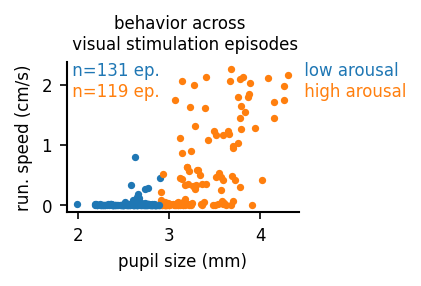

In [18]:
fig, ax = plot_behavior_in_episodes(data, pupil_threshold=2.9)
ax.set_title('behavior across \n visual stimulation episodes')
ax.annotate('\n high arousal', (1, 1), color='tab:orange', xycoords='axes fraction', va='top')
ax.annotate(' low arousal', (1, 1), color='tab:blue', xycoords='axes fraction', va='top')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

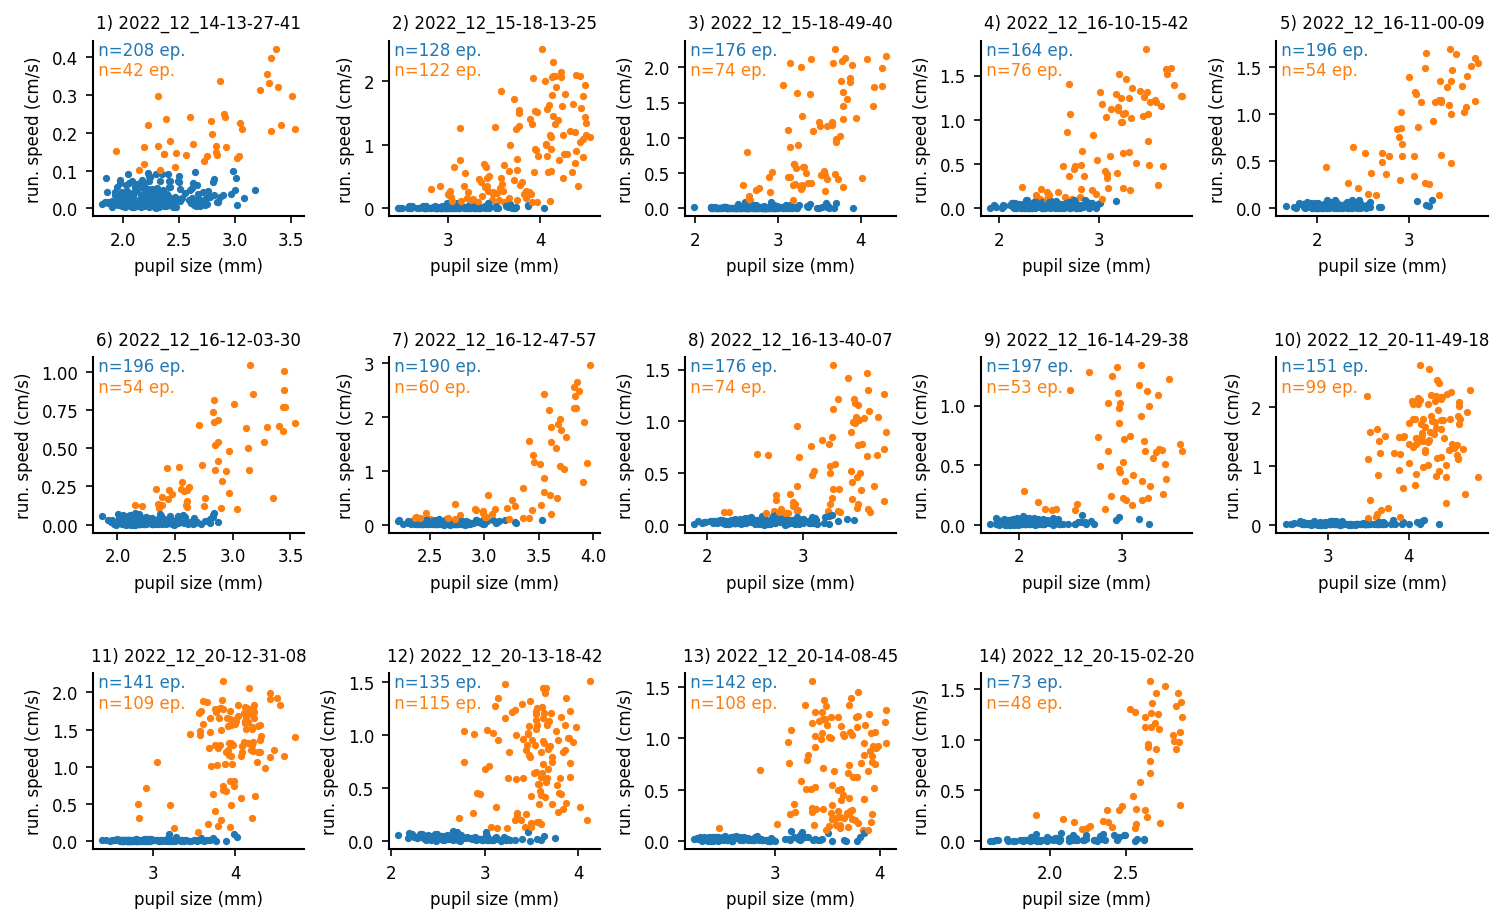

In [19]:
fig, AX = pt.plt.subplots(3, 5, figsize=(12,7))
pt.plt.subplots_adjust(wspace=0.4, hspace=0.8)

for f, filename in enumerate(SESSIONS['files']):
    data = Data(filename, verbose=False)
    plot_behavior_in_episodes(data, ax=AX[int(f/5)][f%5])
    AX[int(f/5)][f%5].set_title(str(f+1)+') '+data.filename.replace('.nwb',''), fontsize=8)
    
AX[-1][-1].axis('off')

In [20]:
protocols = [p for p in data.protocols if (p!='grey-10min')] # remove visual-stimulus-free protocol

STAT_TEST = {}
for protocol in protocols:
    # a default stat test
    STAT_TEST[protocol] = dict(interval_pre=[-1,0],
                               interval_post=[1,2],
                               test='ttest',
                               positive=True)
    
STAT_TEST['looming-stim']['interval_post'] = [2, 3]
STAT_TEST['drifting-gratings']['interval_post'] = [1.5, 2.5]
STAT_TEST['moving-dots']['interval_post'] = [1.5, 2.5]
STAT_TEST['random-dots']['interval_post'] = [1.5, 2.5]
STAT_TEST['static-patch']['interval_post'] = [0.5, 1.5]


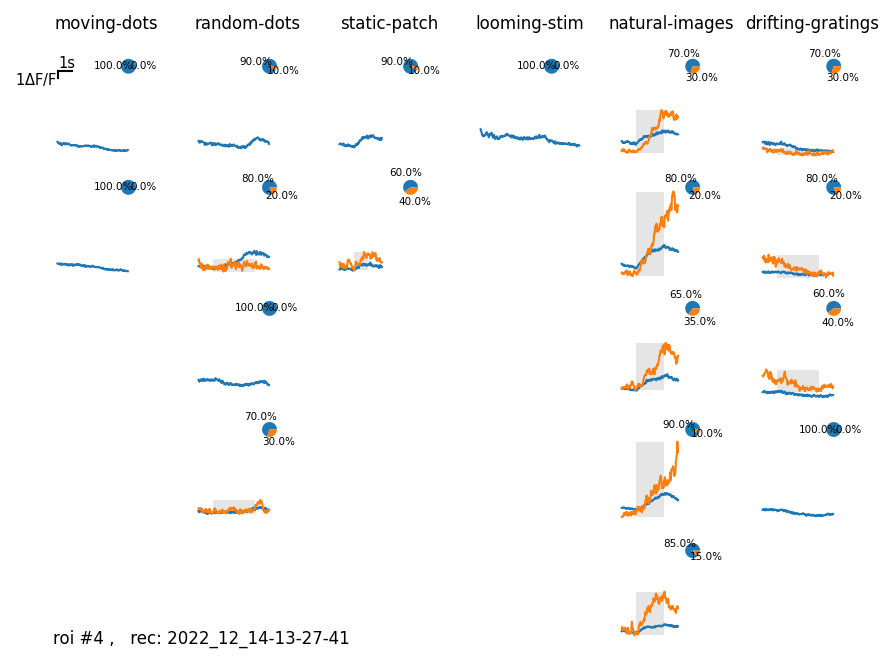

In [79]:
dataIndex, roiIndex = 0, 3
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex, running_speed_threshold=0.1)

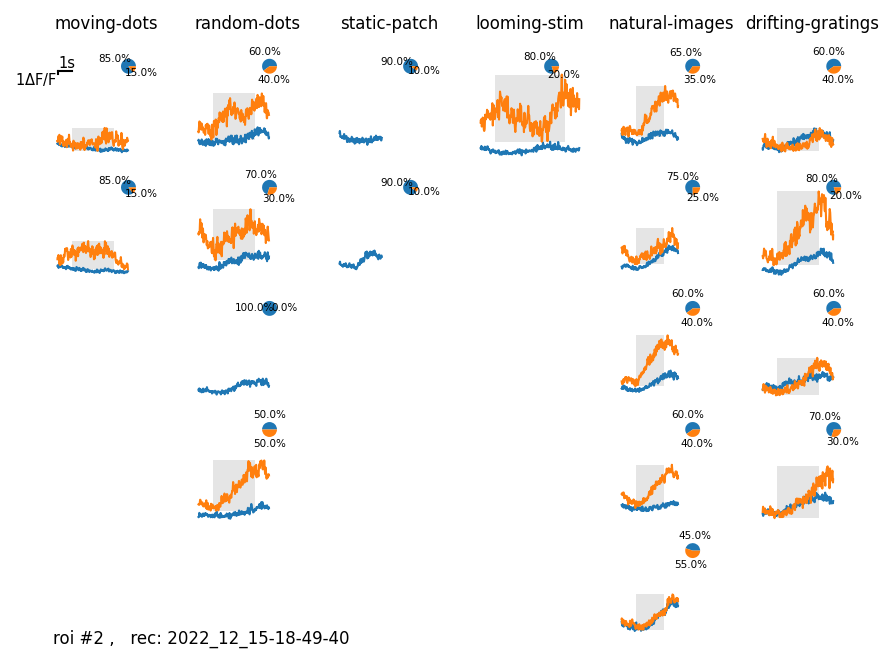

In [80]:
dataIndex, roiIndex = 2, 1
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex)

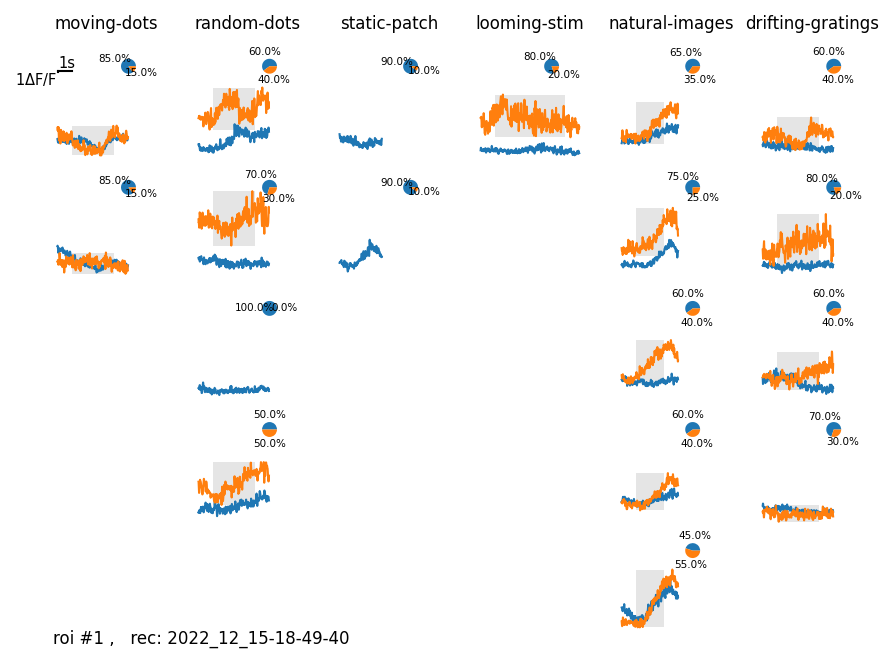

In [81]:
dataIndex, roiIndex = 2, 0
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex)

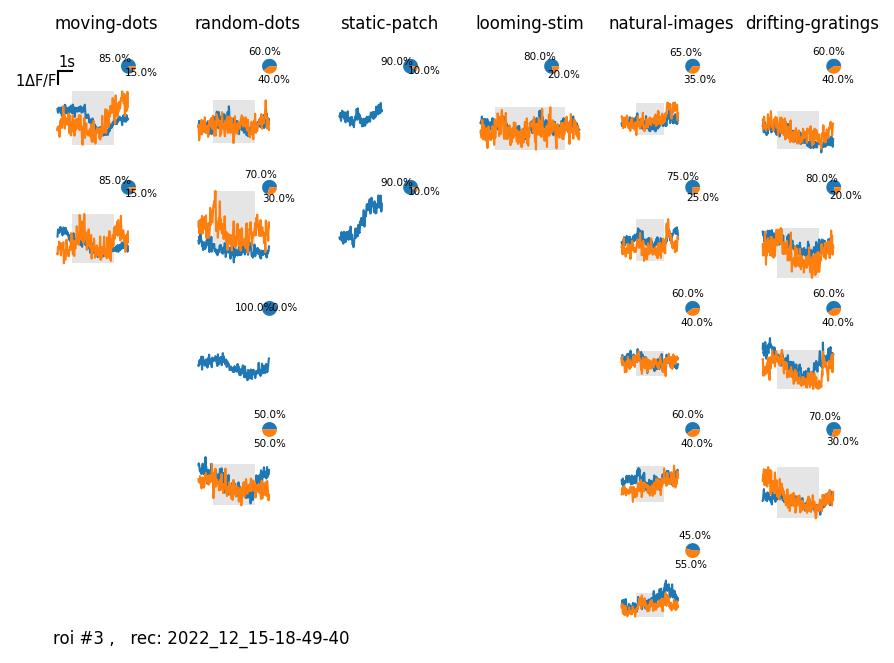

In [82]:
dataIndex, roiIndex = 2, 2
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex)

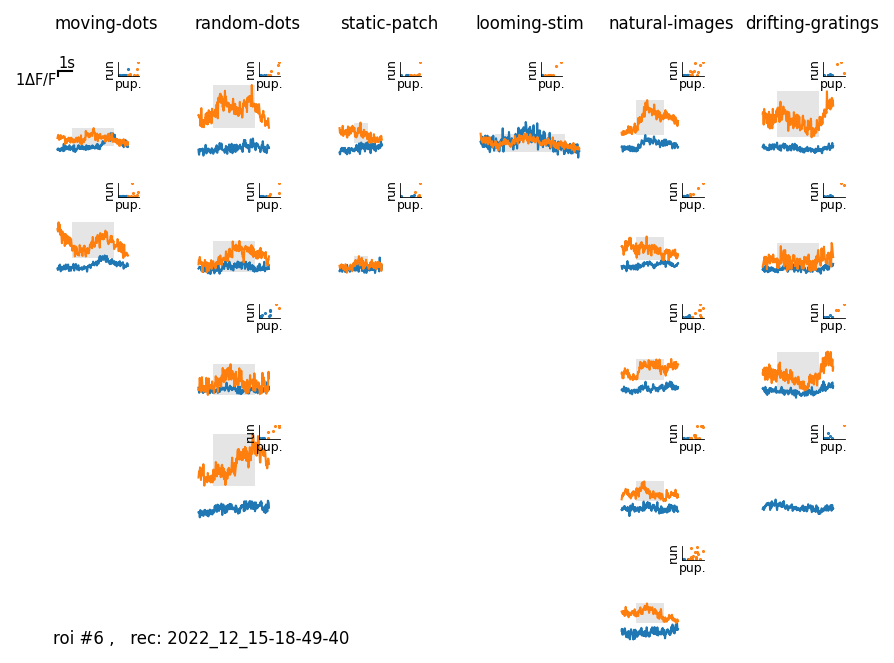

In [83]:
dataIndex, roiIndex = 2, 5
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)

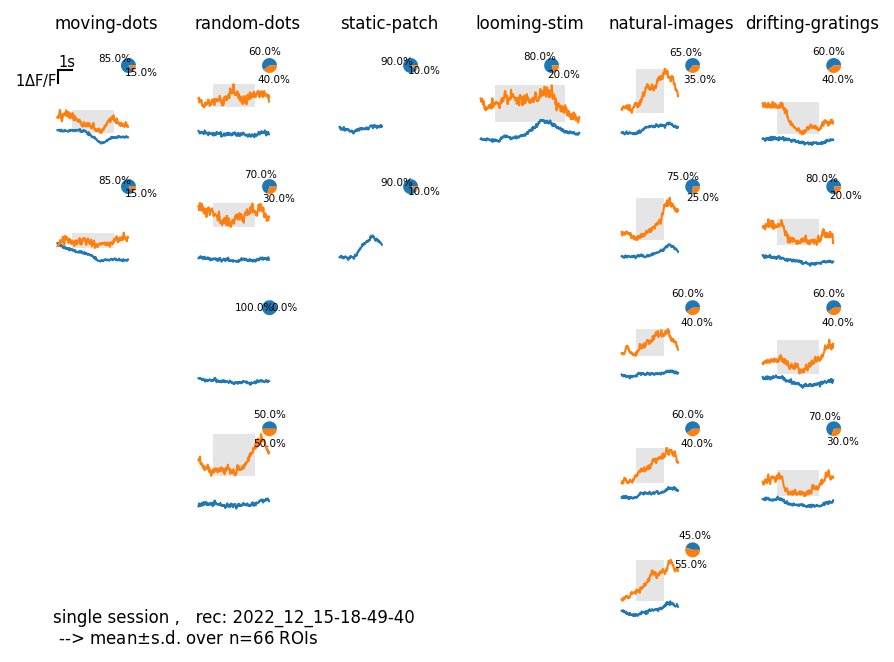

In [84]:
dataIndex, roiIndex = 2, None
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex)

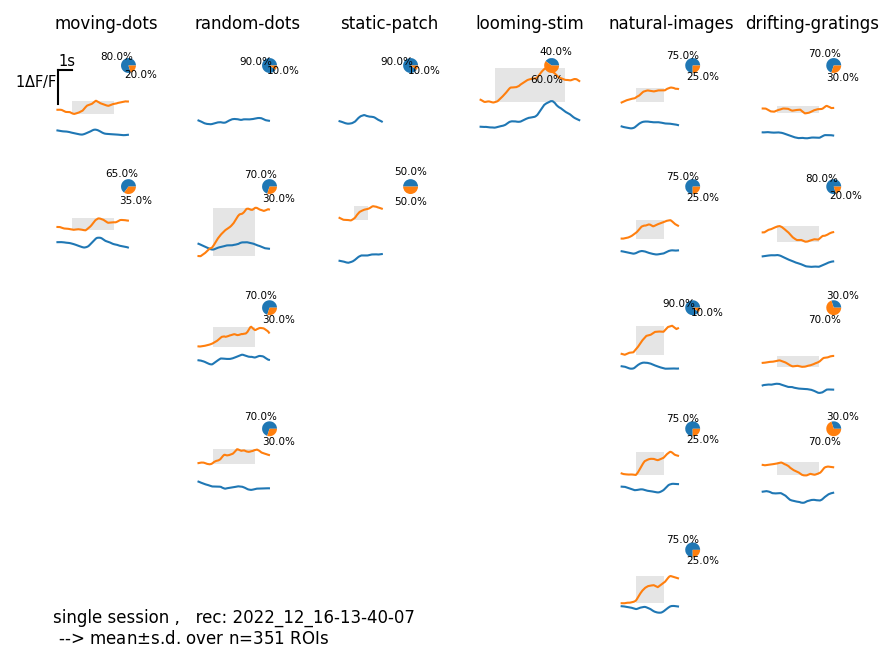

In [85]:
dataIndex, roiIndex = 7, None
data = Data(SESSIONS['files'][dataIndex], verbose=False)
data.build_dFoF(verbose=False)
#fig = plot_average_visually_evoked_activity(data, roiIndex=roiIndex, pupil_threshold=2.9)
fig = plot_average_visually_evoked_activity2(data, roiIndex=roiIndex)